In [47]:
#!pip install jinja2

In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pt
import seaborn as sn 
import missingno as msno
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [49]:
pd.set_option('display.max_columns', None)

In [50]:

df= pd.read_csv("healthcare_supply_chain_01.csv")
df

,record_id,snapshot_date,facility_id,facility_type,department,item_id,item_category,item_subcategory,criticality_level,unit_of_measure,shelf_life_days,avg_daily_usage_last_30d,avg_daily_usage_last_90d,usage_cv_last_90d,demand_trend,seasonal_demand_factor,recent_usage_spike,current_stock_on_hand,safety_stock_level,days_of_supply_on_hand,stock_as_pct_of_safety_level,reorder_point_days,days_until_next_scheduled_order,primary_vendor_id,vendor_reliability_score,contracted_lead_time_days,actual_avg_lead_time_last_6m,lead_time_variability_days,active_po_in_transit,backorder_frequency_last_12m,sole_source_item,substitution_available,facility_census_pct,pandemic_or_surge_flag,days_since_last_stockout,stockout_event
0,SC00000001,2022-06-02,FAC0051,Acute Care Hospital,Emergency Department,ITEM00406,Medications,Biologics & Specialty,High,Each,651,12.1,11.7,0.260,Increasing,1.10,Yes,168,229,13.9,73.4,10.7,14,VND035,3.4,7,8.0,0.7,No,2,No,No,68.5,No,240,0
1,SC00000002,2024-07-16,FAC0116,Long-Term Care,Operating Room,ITEM00106,Medications,IV Medications,Medium,Case,80,10.0,8.2,0.412,Increasing,1.09,No,24,132,2.4,18.2,12.1,14,VND059,3.2,7,8.7,2.4,Yes,1,No,No,31.7,No,276,0
2,SC00000003,2024-08-22,FAC0198,Specialty Hospital,Emergency Department,ITEM00281,Surgical Supplies,Sponges & Gauze,High,Box,884,19.4,17.3,0.215,Increasing,1.25,No,772,630,39.8,122.5,18.1,28,VND023,2.5,12,15.7,0.4,No,1,No,No,72.2,No,74,0
3,SC00000004,2021-11-02,FAC0148,Acute Care Hospital,Operating Room,ITEM00425,Medications,Oral Medications,High,Case,507,26.0,29.7,0.171,Stable,1.10,No,315,416,12.1,75.7,7.0,14,VND081,3.2,3,3.6,1.4,No,2,No,No,39.8,No,87,0
4,SC00000005,2022-04-26,FAC0059,Long-Term Care,Emergency Department,ITEM00029,Implants & Prosthetics,Cardiovascular Implants,High,Each,1670,5.5,5.3,0.284,Decreasing,0.83,No,357,278,64.9,128.4,31.6,21,VND015,3.4,27,27.6,2.0,Yes,2,Yes,No,63.4,Yes,725,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89083,SC00089084,2021-03-24,FAC0157,Ambulatory Surgery Center,Sterile Processing,ITEM00128,Lab Consumables,PCR Consumables,High,Box,30,39.7,54.6,0.243,Stable,0.81,No,1362,841,34.3,162.0,8.7,14,VND043,3.5,4,3.8,2.9,Yes,2,No,Yes,73.6,No,83,0
89084,SC00089085,2023-07-18,FAC0079,Ambulatory Surgery Center,Operating Room,ITEM00386,IV & Fluids,TPN Components,High,Kit,566,23.8,25.9,0.275,Increasing,1.16,No,224,1251,9.4,17.9,35.0,21,VND021,3.4,24,29.5,3.5,Yes,0,No,Yes,67.1,No,143,1
89085,SC00089086,2024-09-16,FAC0061,Long-Term Care,Med-Surg,ITEM00203,Surgical Supplies,Needles & Syringes,High,Roll,834,13.3,18.7,0.057,Increasing,1.35,Yes,12,275,0.9,4.4,10.1,7,VND059,3.2,7,7.7,0.4,Yes,0,No,Yes,72.6,No,282,0
89086,SC00089087,2024-05-10,FAC0056,Specialty Hospital,ICU,ITEM00057,Surgical Supplies,Sutures & Staples,Medium,Case,1263,23.9,24.3,0.191,Increasing,0.99,No,194,154,8.1,126.0,3.7,7,VND057,3.1,2,2.2,0.5,Yes,1,No,Yes,76.7,No,155,0


In [51]:
df.columns


Index(['record_id', 'snapshot_date', 'facility_id', 'facility_type',
       'department', 'item_id', 'item_category', 'item_subcategory',
       'criticality_level', 'unit_of_measure', 'shelf_life_days',
       'avg_daily_usage_last_30d', 'avg_daily_usage_last_90d',
       'usage_cv_last_90d', 'demand_trend', 'seasonal_demand_factor',
       'recent_usage_spike', 'current_stock_on_hand', 'safety_stock_level',
       'days_of_supply_on_hand', 'stock_as_pct_of_safety_level',
       'reorder_point_days', 'days_until_next_scheduled_order',
       'primary_vendor_id', 'vendor_reliability_score',
       'contracted_lead_time_days', 'actual_avg_lead_time_last_6m',
       'lead_time_variability_days', 'active_po_in_transit',
       'backorder_frequency_last_12m', 'sole_source_item',
       'substitution_available', 'facility_census_pct',
       'pandemic_or_surge_flag', 'days_since_last_stockout', 'stockout_event'],
      dtype='str')

In [52]:
pd.set_option('display.max_columns', None)
df.info ()


<class 'pandas.DataFrame'>
RangeIndex: 89088 entries, 0 to 89087
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   record_id                        89088 non-null  str    
 1   snapshot_date                    89088 non-null  str    
 2   facility_id                      89088 non-null  str    
 3   facility_type                    89088 non-null  str    
 4   department                       89088 non-null  str    
 5   item_id                          89088 non-null  str    
 6   item_category                    89088 non-null  str    
 7   item_subcategory                 89088 non-null  str    
 8   criticality_level                89088 non-null  str    
 9   unit_of_measure                  89088 non-null  str    
 10  shelf_life_days                  89088 non-null  int64  
 11  avg_daily_usage_last_30d         89088 non-null  float64
 12  avg_daily_usage_last_90d     

In [53]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
print(categorical_cols)



Index(['record_id', 'snapshot_date', 'facility_id', 'facility_type',
       'department', 'item_id', 'item_category', 'item_subcategory',
       'criticality_level', 'unit_of_measure', 'demand_trend',
       'recent_usage_spike', 'primary_vendor_id', 'active_po_in_transit',
       'sole_source_item', 'substitution_available', 'pandemic_or_surge_flag'],
      dtype='str')


In [54]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['shelf_life_days', 'avg_daily_usage_last_30d',
       'avg_daily_usage_last_90d', 'usage_cv_last_90d',
       'seasonal_demand_factor', 'current_stock_on_hand', 'safety_stock_level',
       'days_of_supply_on_hand', 'stock_as_pct_of_safety_level',
       'reorder_point_days', 'days_until_next_scheduled_order',
       'vendor_reliability_score', 'contracted_lead_time_days',
       'actual_avg_lead_time_last_6m', 'lead_time_variability_days',
       'backorder_frequency_last_12m', 'facility_census_pct',
       'days_since_last_stockout', 'stockout_event'],
      dtype='str')


In [55]:
df[categorical_cols ].describe()


,record_id,snapshot_date,facility_id,facility_type,department,item_id,item_category,item_subcategory,criticality_level,unit_of_measure,demand_trend,recent_usage_spike,primary_vendor_id,active_po_in_transit,sole_source_item,substitution_available,pandemic_or_surge_flag
count,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088,89088
unique,89088,1042,194,5,13,442,7,28,4,8,3,2,82,2,2,2,2
top,SC00000001,2023-03-22,FAC0024,Acute Care Hospital,Operating Room,ITEM00308,Surgical Supplies,Drapes & Gowns,High,Each,Stable,No,VND034,Yes,No,Yes,No
freq,1,113,4331,40846,20997,2583,20456,6182,34386,24049,53345,75632,8507,51801,80801,48680,84239


In [56]:
df[numerical_cols].describe()


,shelf_life_days,avg_daily_usage_last_30d,avg_daily_usage_last_90d,usage_cv_last_90d,seasonal_demand_factor,current_stock_on_hand,safety_stock_level,days_of_supply_on_hand,stock_as_pct_of_safety_level,reorder_point_days,days_until_next_scheduled_order,vendor_reliability_score,contracted_lead_time_days,actual_avg_lead_time_last_6m,lead_time_variability_days,backorder_frequency_last_12m,facility_census_pct,days_since_last_stockout,stockout_event
count,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000,89088.000000
mean,619.627144,43.940825,44.667487,0.250034,1.014826,961.112002,865.452104,21.824967,142.958460,13.253209,11.613809,3.598102,9.651087,10.324663,1.347480,1.136079,63.299853,119.374046,0.218615
std,470.927225,45.906133,47.964303,0.143729,0.121722,1736.359108,1086.172225,22.088913,178.091275,7.355433,7.102507,0.603142,6.357109,7.088433,1.469132,1.154062,17.801621,118.542874,0.413309
min,30.000000,0.300000,0.300000,0.020000,0.650000,0.000000,2.000000,0.500000,0.000000,2.500000,1.000000,2.300000,2.000000,1.400000,0.000000,0.000000,20.000000,1.000000,0.000000
25%,254.000000,16.300000,16.100000,0.139000,0.930000,125.000000,260.000000,5.700000,28.300000,7.700000,7.000000,3.100000,4.000000,4.800000,0.400000,0.000000,51.200000,34.000000,0.000000
50%,498.000000,30.000000,30.000000,0.229000,1.010000,383.000000,529.000000,13.700000,76.700000,11.200000,7.000000,3.500000,7.000000,8.100000,0.900000,1.000000,65.100000,82.000000,0.000000
75%,928.000000,55.200000,55.800000,0.340000,1.100000,1070.000000,1054.250000,32.000000,186.400000,16.700000,14.000000,4.100000,13.000000,13.700000,1.800000,2.000000,77.000000,166.000000,0.000000
max,2837.000000,811.000000,818.700000,0.897000,1.510000,82108.000000,25362.000000,120.000000,999.900000,48.700000,28.000000,4.900000,27.000000,44.000000,20.000000,10.000000,99.800000,730.000000,1.000000


In [57]:

df.duplicated().sum(   )

np.int64(0)

In [58]:
df.nunique()

record_id                          89088
snapshot_date                       1042
facility_id                          194
facility_type                          5
department                            13
item_id                              442
item_category                          7
item_subcategory                      28
criticality_level                      4
unit_of_measure                        8
shelf_life_days                      369
avg_daily_usage_last_30d            2865
avg_daily_usage_last_90d            2946
usage_cv_last_90d                    797
demand_trend                           3
seasonal_demand_factor                85
recent_usage_spike                     2
current_stock_on_hand               6781
safety_stock_level                  5229
days_of_supply_on_hand              1175
stock_as_pct_of_safety_level        7400
reorder_point_days                   406
days_until_next_scheduled_order        6
primary_vendor_id                     82
vendor_reliabili

In [59]:
for i in categorical_cols:
    print(f"unique values for {i}:")
    print(df[i].unique())
    print("\n")
    


unique values for record_id:
<StringArray>
['SC00000001', 'SC00000002', 'SC00000003', 'SC00000004', 'SC00000005',
 'SC00000006', 'SC00000007', 'SC00000008', 'SC00000009', 'SC00000010',
 ...
 'SC00089079', 'SC00089080', 'SC00089081', 'SC00089082', 'SC00089083',
 'SC00089084', 'SC00089085', 'SC00089086', 'SC00089087', 'SC00089088']
Length: 89088, dtype: str


unique values for snapshot_date:
<StringArray>
['2022-06-02', '2024-07-16', '2024-08-22', '2021-11-02', '2022-04-26',
 '2021-02-18', '2022-03-30', '2022-07-04', '2024-03-28', '2024-09-11',
 ...
 '2021-12-10', '2024-10-31', '2023-12-01', '2021-07-02', '2023-02-24',
 '2022-06-13', '2022-03-31', '2022-10-06', '2022-04-04', '2021-07-29']
Length: 1042, dtype: str


unique values for facility_id:
<StringArray>
['FAC0051', 'FAC0116', 'FAC0198', 'FAC0148', 'FAC0059', 'FAC0111', 'FAC0197',
 'FAC0089', 'FAC0038', 'FAC0057',
 ...
 'FAC0094', 'FAC0026', 'FAC0041', 'FAC0100', 'FAC0028', 'FAC0036', 'FAC0029',
 'FAC0025', 'FAC0154', 'FAC0163']
Len

In [60]:
for i in categorical_cols:
    print(f"value counts for {i}:")
    print(df[i].value_counts())
    print("\n")

value counts for record_id:
record_id
SC00000001    1
SC00000002    1
SC00000003    1
SC00000004    1
SC00000005    1
             ..
SC00089084    1
SC00089085    1
SC00089086    1
SC00089087    1
SC00089088    1
Name: count, Length: 89088, dtype: int64


value counts for snapshot_date:
snapshot_date
2023-03-22    113
2024-11-11    112
2022-10-28    112
2024-05-24    111
2021-03-23    111
             ... 
2023-07-14     64
2024-04-17     64
2023-06-07     64
2021-02-10     63
2023-10-16     61
Name: count, Length: 1042, dtype: int64


value counts for facility_id:
facility_id
FAC0024    4331
FAC0145    4321
FAC0056    2606
FAC0148    2593
FAC0197    2454
           ... 
FAC0028       1
FAC0029       1
FAC0025       1
FAC0154       1
FAC0163       1
Name: count, Length: 194, dtype: int64


value counts for facility_type:
facility_type
Acute Care Hospital          40846
Ambulatory Surgery Center    20502
Specialty Hospital           14987
Outpatient Clinic             6588
Long-Term Ca

In [61]:
IDENTIFIERS = ['record_id','snapshot_date','facility_id','facility_type',
               'department','item_id','item_category','item_subcategory',
               'unit_of_measure','primary_vendor_id']

DEMAND_FEATURES = ['avg_daily_usage_last_30d','avg_daily_usage_last_90d',
                   'usage_cv_last_90d','demand_trend','seasonal_demand_factor',
                   'recent_usage_spike']

CONTEXTUAL_FEATURES = ['criticality_level','shelf_life_days',
                       'facility_census_pct','pandemic_or_surge_flag']

SUPPLY_CHAIN_FEATURES = ['vendor_reliability_score','contracted_lead_time_days',
                         'actual_avg_lead_time_last_6m','lead_time_variability_days',
                         'active_po_in_transit','backorder_frequency_last_12m',
                         'sole_source_item','substitution_available']

STOCK_FEATURES = ['current_stock_on_hand','safety_stock_level','days_of_supply_on_hand',
                  'stock_as_pct_of_safety_level','reorder_point_days',
                  'days_until_next_scheduled_order','days_since_last_stockout']

TARGET = ['stockout_event']

ALL_GROUPS = {
    'Identifiers': IDENTIFIERS,
    'Demand': DEMAND_FEATURES,
    'Contextual': CONTEXTUAL_FEATURES,
    'Supply Chain': SUPPLY_CHAIN_FEATURES,
    'Stock Position': STOCK_FEATURES,
    'Target': TARGET
}

for group, cols in ALL_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    print(f'{group:15s}: {len(present):2d} present  {"❌ MISSING: " + str(missing) if missing else "✅"}')

Identifiers    : 10 present  ✅
Demand         :  6 present  ✅
Contextual     :  4 present  ✅
Supply Chain   :  8 present  ✅
Stock Position :  7 present  ✅
Target         :  1 present  ✅


In [62]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2),
    'nunique': df.nunique(),
    'sample': df.iloc[0],
    'unique_values': [[df[c].unique() if df[c].dtype == 'object' else ''] for c in df.columns ]
})
summary.style.background_gradient(subset=['null_pct'], cmap='OrRd')

,dtype,null_count,null_pct,nunique,sample,unique_values
record_id,str,0,0.000000,89088,SC00000001,['']
snapshot_date,str,0,0.000000,1042,2022-06-02,['']
facility_id,str,0,0.000000,194,FAC0051,['']
facility_type,str,0,0.000000,5,Acute Care Hospital,['']
department,str,0,0.000000,13,Emergency Department,['']
item_id,str,0,0.000000,442,ITEM00406,['']
item_category,str,0,0.000000,7,Medications,['']
item_subcategory,str,0,0.000000,28,Biologics & Specialty,['']
criticality_level,str,0,0.000000,4,High,['']
unit_of_measure,str,0,0.000000,8,Each,['']


C:\Users\Techsupport.umapathi\AppData\Local\Temp\ipykernel_9728\646182311.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pt.tight_layout()


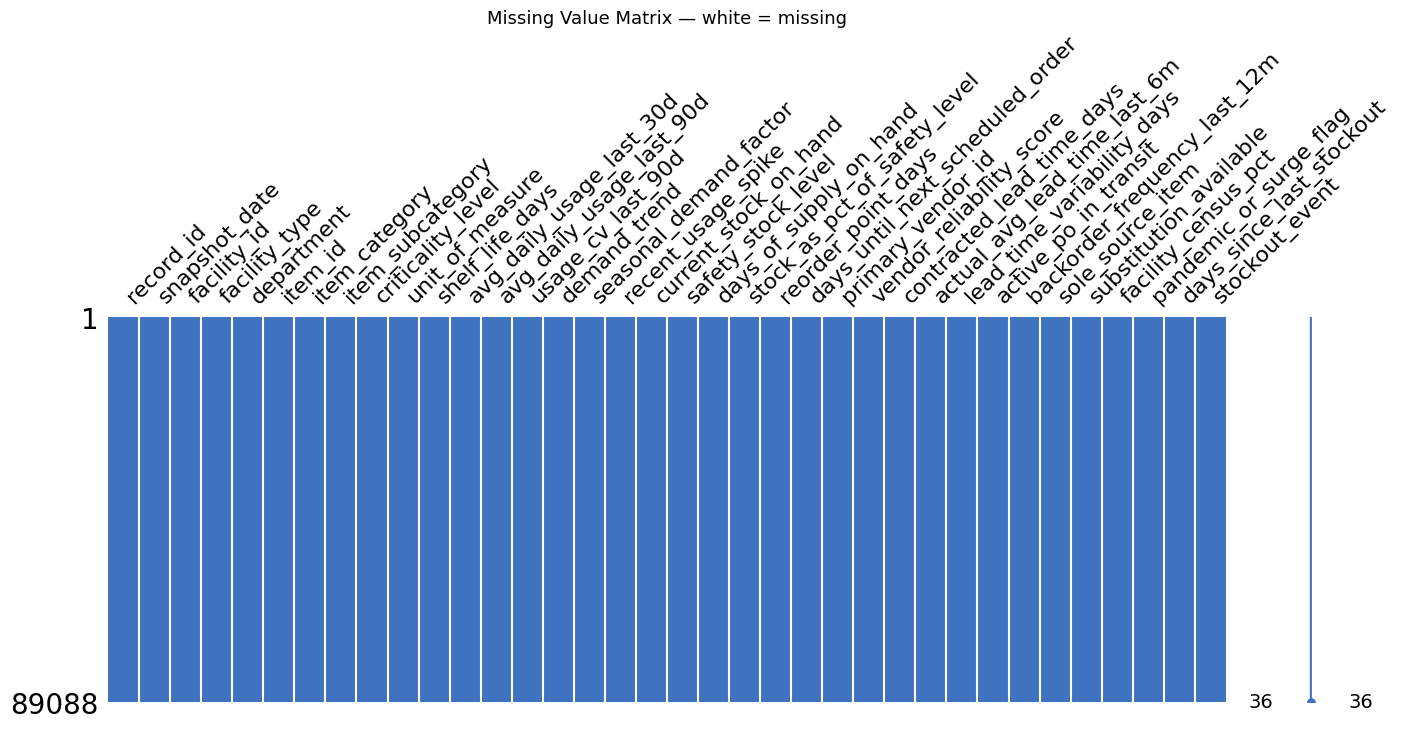

In [63]:
msno.matrix(df, figsize=(16, 5), color=(0.25, 0.45, 0.75))
pt.title('Missing Value Matrix — white = missing', fontsize=13)
pt.tight_layout()
pt.show()

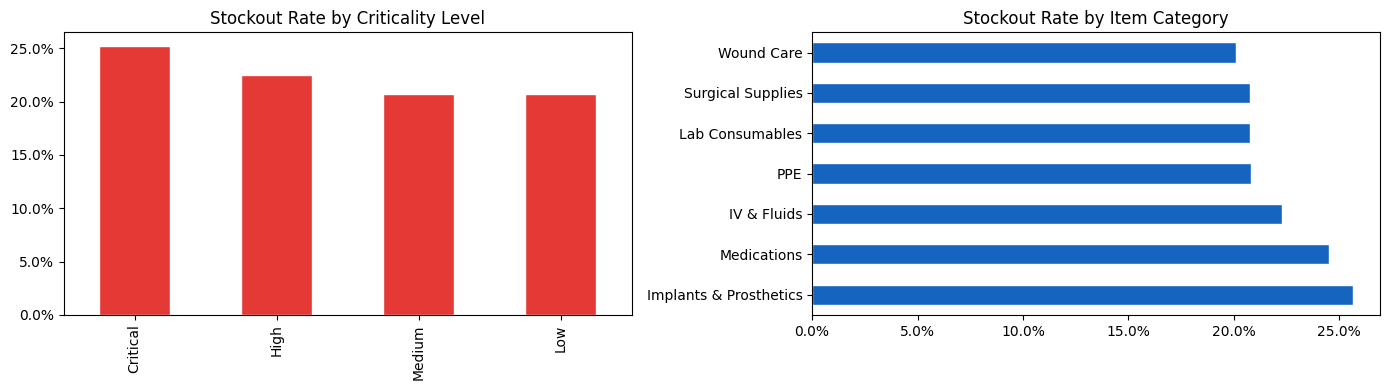

In [64]:
# ── Stockout rate by criticality ──────────────────────────────────────────────

fig, axes = pt.subplots(1, 2, figsize=(14, 4))

stockout_by_crit = df.groupby('criticality_level')['stockout_event'].mean().sort_values(ascending=False)
stockout_by_crit.plot(kind='bar', ax=axes[0], color='#E53935', edgecolor='white')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Stockout Rate by Criticality Level')
axes[0].set_xlabel('')

stockout_by_cat = df.groupby('item_category')['stockout_event'].mean().sort_values(ascending=False)
stockout_by_cat.plot(kind='barh', ax=axes[1], color='#1565C0', edgecolor='white')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Stockout Rate by Item Category')
axes[1].set_ylabel('')

pt.tight_layout()
pt.show()

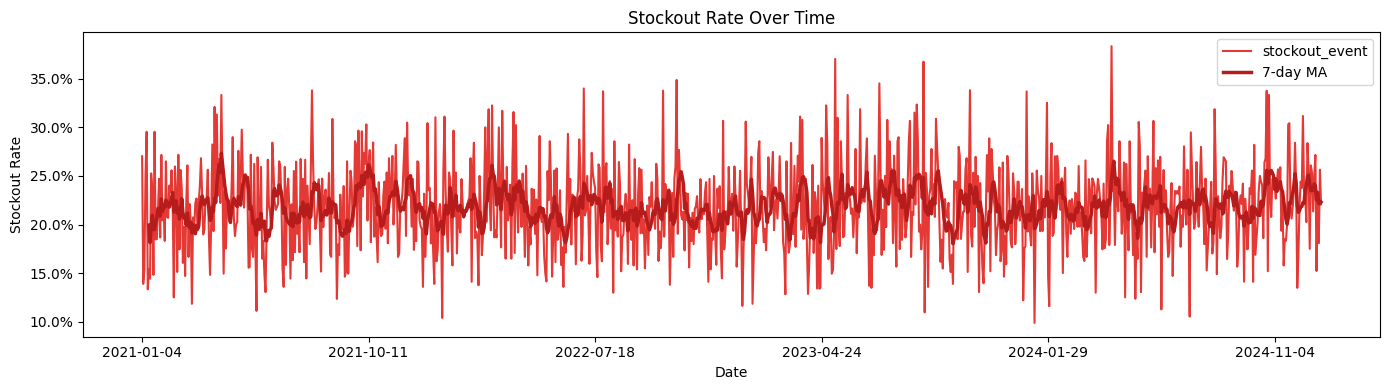

In [65]:
# ── Stockout rate over time ───────────────────────────────────────────────────
stockout_ts = df.groupby('snapshot_date')['stockout_event'].mean()

pt.figure(figsize=(14, 4))
stockout_ts.plot(color='#E53935', linewidth=1.5)
stockout_ts.rolling(7).mean().plot(color='#B71C1C', linewidth=2.5, label='7-day MA')
pt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
pt.title('Stockout Rate Over Time')
pt.xlabel('Date')
pt.ylabel('Stockout Rate')
pt.legend()
pt.tight_layout()
pt.show()

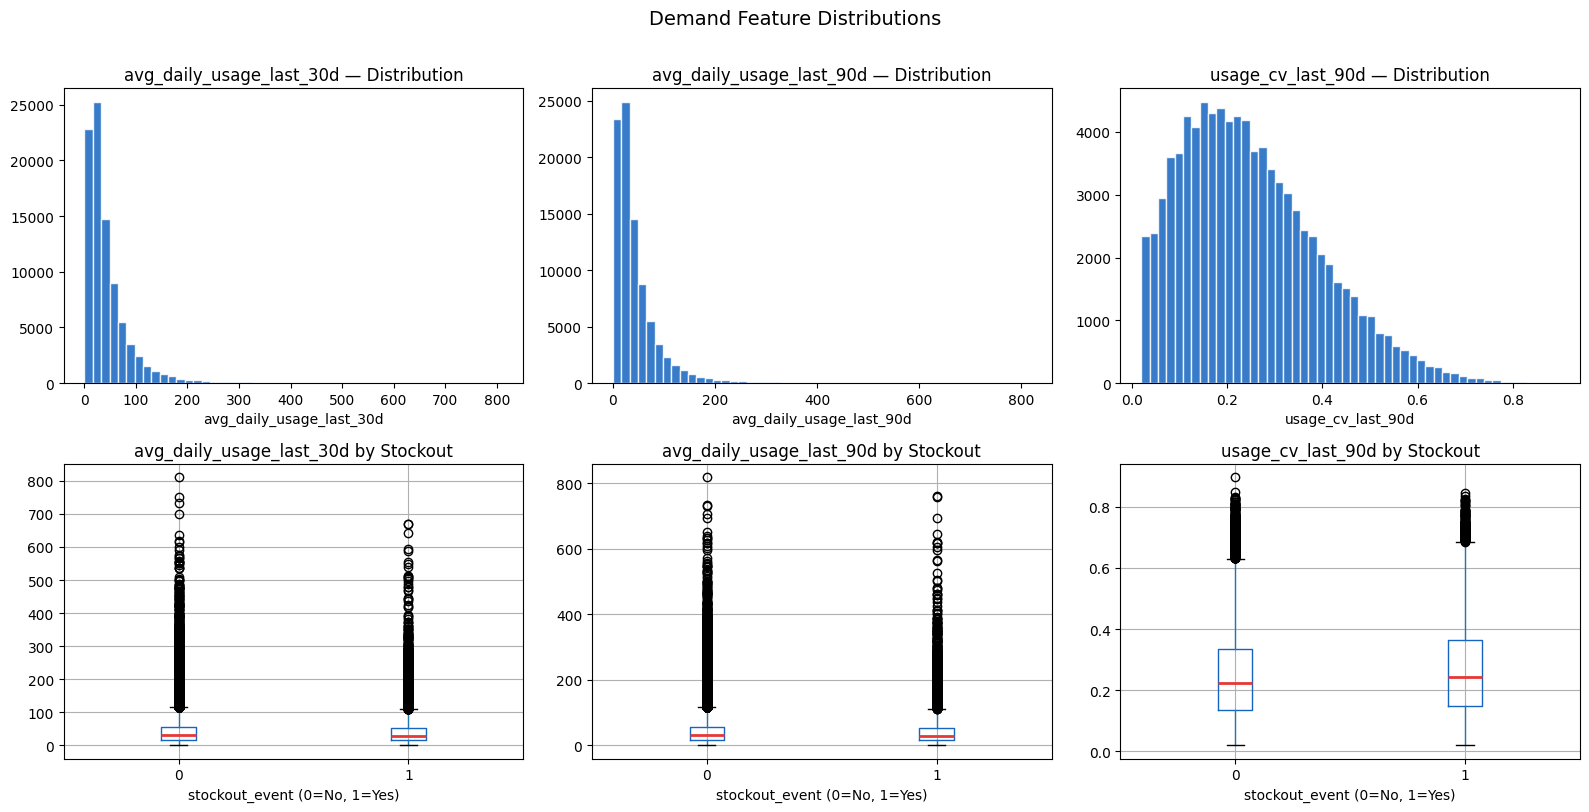

In [66]:
demand_cols = ['avg_daily_usage_last_30d','avg_daily_usage_last_90d','usage_cv_last_90d']

fig, axes = pt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(demand_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=50, color='#1565C0', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)

    # Boxplot split by stockout
    df.boxplot(column=col, by='stockout_event', ax=axes[1, i],
               boxprops=dict(color='#1565C0'),
               medianprops=dict(color='#E53935', linewidth=2))
    axes[1, i].set_title(f'{col} by Stockout')
    axes[1, i].set_xlabel('stockout_event (0=No, 1=Yes)')

pt.suptitle('Demand Feature Distributions', y=1.01, fontsize=14)
pt.tight_layout()
pt.show()

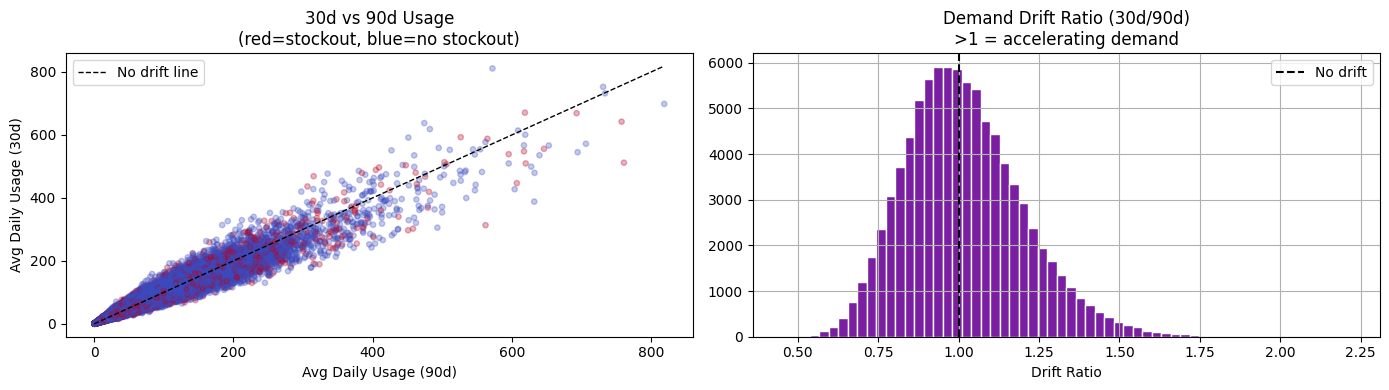

Items with accelerating demand (ratio>1.2): 13,766 (15.5%)


In [67]:
# ── 30d vs 90d usage — drift detection ───────────────────────────────────────
df['demand_drift'] = df['avg_daily_usage_last_30d'] / df['avg_daily_usage_last_90d'].replace(0, np.nan)

fig, axes = pt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['avg_daily_usage_last_90d'], df['avg_daily_usage_last_30d'],
                alpha=0.3, s=15, c=df['stockout_event'], cmap='coolwarm')
axes[0].plot([0, df['avg_daily_usage_last_90d'].max()],
             [0, df['avg_daily_usage_last_90d'].max()], 'k--', lw=1, label='No drift line')
axes[0].set_xlabel('Avg Daily Usage (90d)')
axes[0].set_ylabel('Avg Daily Usage (30d)')
axes[0].set_title('30d vs 90d Usage\n(red=stockout, blue=no stockout)')
axes[0].legend()

df['demand_drift'].clip(-1, 5).hist(bins=60, ax=axes[1], color='#7B1FA2', edgecolor='white')
axes[1].axvline(1.0, color='black', linestyle='--', label='No drift')
axes[1].set_title('Demand Drift Ratio (30d/90d)\n>1 = accelerating demand')
axes[1].set_xlabel('Drift Ratio')
axes[1].legend()

pt.tight_layout()
pt.show()

print(f'Items with accelerating demand (ratio>1.2): {(df["demand_drift"]>1.2).sum():,} ({(df["demand_drift"]>1.2).mean()*100:.1f}%)')

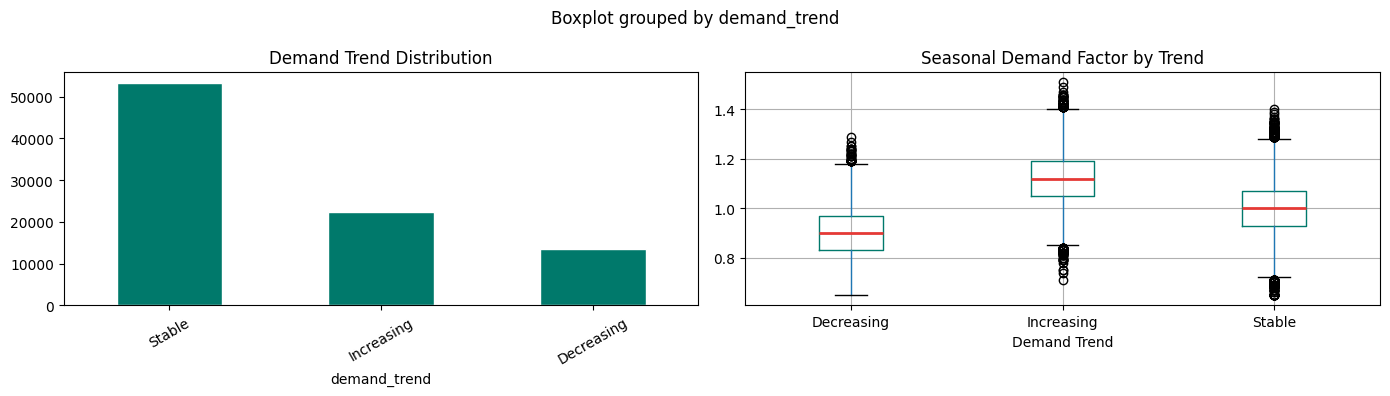

In [68]:
fig, axes = pt.subplots(1, 2, figsize=(14, 4))

trend_counts = df['demand_trend'].value_counts()
trend_counts.plot(kind='bar', ax=axes[0], color='#00796B', edgecolor='white')
axes[0].set_title('Demand Trend Distribution')
axes[0].set_xticklabels(trend_counts.index, rotation=30)

df.boxplot(column='seasonal_demand_factor', by='demand_trend', ax=axes[1],
           boxprops=dict(color='#00796B'),
           medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title('Seasonal Demand Factor by Trend')
axes[1].set_xlabel('Demand Trend')

pt.tight_layout()
pt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

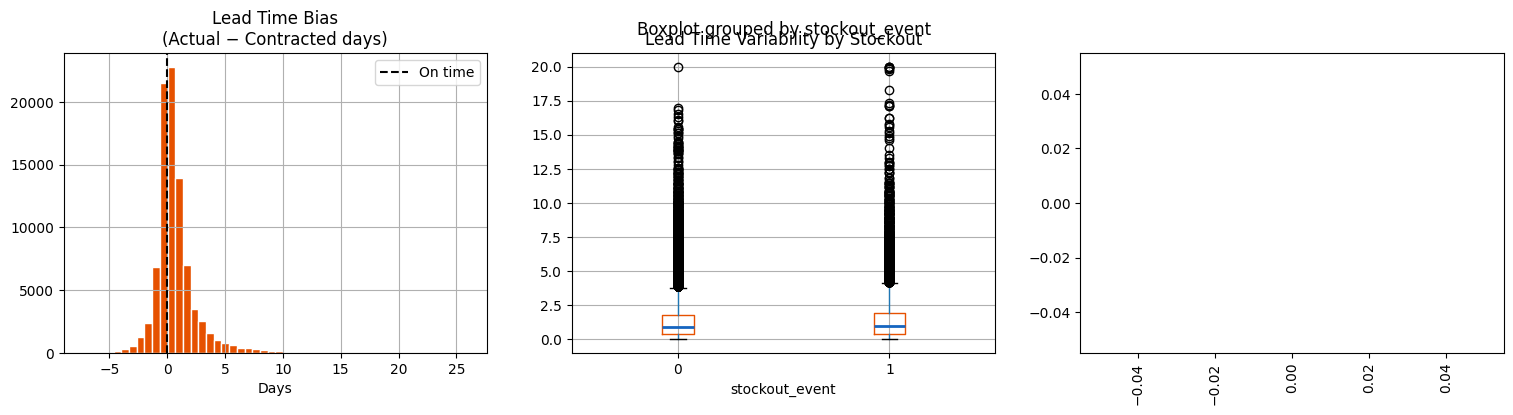

In [69]:
# ── Lead time analysis ────────────────────────────────────────────────────────
df['lead_time_bias'] = df['actual_avg_lead_time_last_6m'] - df['contracted_lead_time_days']

fig, axes = pt.subplots(1, 3, figsize=(18, 4))

# Lead time bias distribution
df['lead_time_bias'].hist(bins=50, ax=axes[0], color='#E65100', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', lw=1.5, label='On time')
axes[0].set_title('Lead Time Bias\n(Actual − Contracted days)')
axes[0].set_xlabel('Days')
axes[0].legend()

# Lead time variability vs stockout
df.boxplot(column='lead_time_variability_days', by='stockout_event', ax=axes[1],
           boxprops=dict(color='#E65100'),
           medianprops=dict(color='#1565C0', linewidth=2))
axes[1].set_title('Lead Time Variability by Stockout')
axes[1].set_xlabel('stockout_event')

# Vendor reliability vs stockout rate
df['vendor_reliability_bin'] = pd.cut(df['vendor_reliability_score'],
                                       bins=[0, 0.6, 0.75, 0.9, 1.01],
                                       labels=['Low (<0.6)','Medium (0.6-0.75)',
                                               'High (0.75-0.9)','Excellent (>0.9)'])
vr_stockout = df.groupby('vendor_reliability_bin', observed=True)['stockout_event'].mean()
vr_stockout.plot(kind='bar', ax=axes[2], color='#1565C0', edgecolor='white')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title('Stockout Rate by Vendor Reliability')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20)

pt.tight_layout()
pt.show()

pct_late = (df['lead_time_bias'] > 0).mean()
print(f'Vendors delivering LATE (actual > contracted): {pct_late*100:.1f}%')

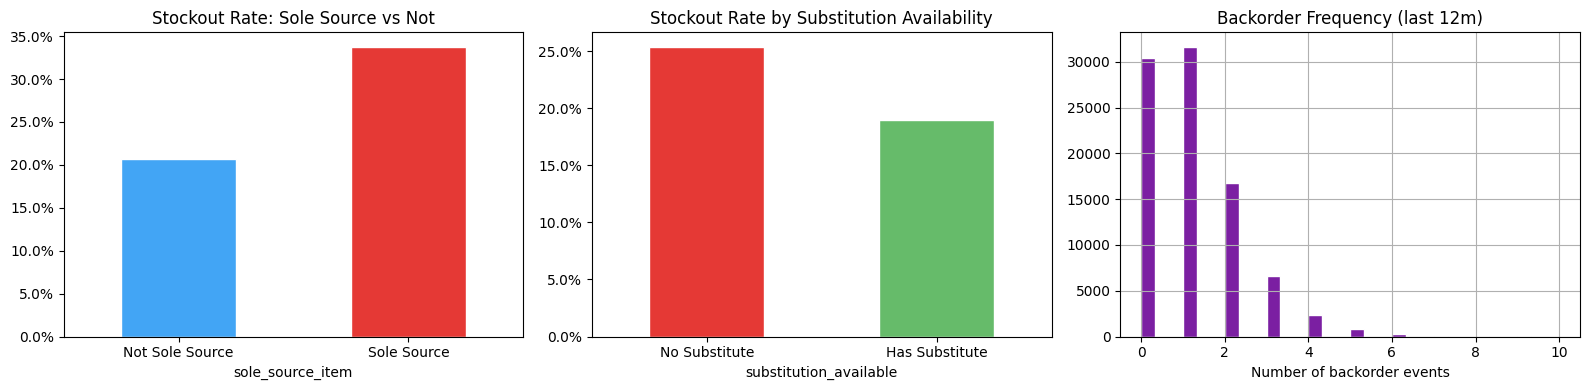

In [ ]:
# ── Sole source & backorder analysis ─────────────────────────────────────────
fig, axes = pt.subplots(1, 3, figsize=(16, 4))

# Sole source stockout rate
ss_rate = df.groupby('sole_source_item')['stockout_event'].mean()
ss_rate.plot(kind='bar', ax=axes[0], color=['#42A5F5','#E53935'], edgecolor='white')
axes[0].set_xticklabels(['Not Sole Source','Sole Source'], rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Stockout Rate: Sole Source vs Not')

# Substitution availability
sub_rate = df.groupby('substitution_available')['stockout_event'].mean()
sub_rate.plot(kind='bar', ax=axes[1], color=['#E53935','#66BB6A'], edgecolor='white')
axes[1].set_xticklabels(['No Substitute','Has Substitute'], rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Stockout Rate by Substitution Availability')

# Backorder frequency distribution
df['backorder_frequency_last_12m'].hist(bins=30, ax=axes[2],
                                         color='#7B1FA2', edgecolor='white')
axes[2].set_title('Backorder Frequency (last 12m)')
axes[2].set_xlabel('Number of backorder events')

pt.tight_layout()
pt.show()

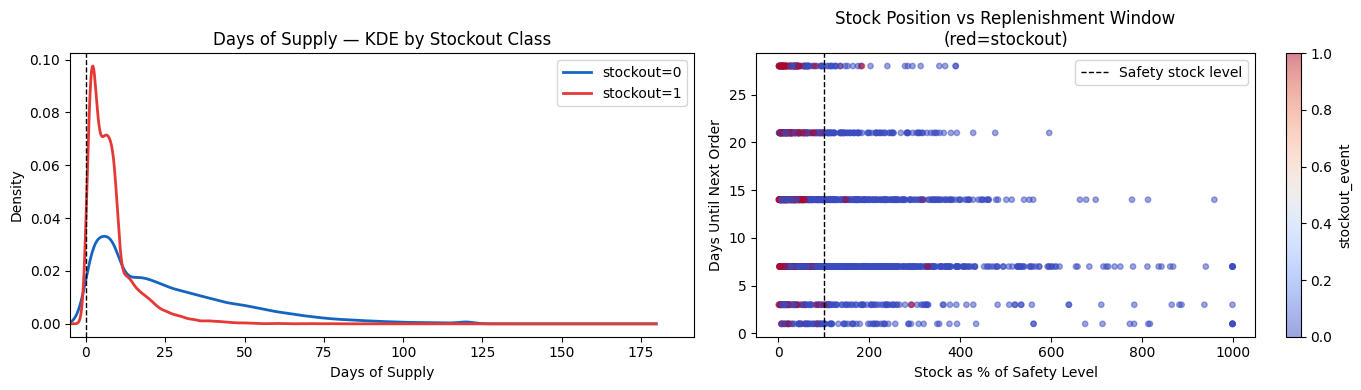

In [ ]:
# ── Days of supply vs stockout ────────────────────────────────────────────────
fig, axes = pt.subplots(1, 2, figsize=(14, 4))

# KDE by class
for label, color in [(0,'#1565C0'),(1,'#E53935')]:
    subset = df[df['stockout_event']==label]['days_of_supply_on_hand'].dropna()
    subset.plot.kde(ax=axes[0], label=f'stockout={label}', color=color, linewidth=2)
axes[0].set_title('Days of Supply — KDE by Stockout Class')
axes[0].set_xlabel('Days of Supply')
axes[0].set_xlim(left=-5)
axes[0].legend()
axes[0].axvline(0, color='black', linestyle='--', lw=1)

# Stock % vs safety level scatter
sample = df.sample(min(2000, len(df)), random_state=42)
scatter = axes[1].scatter(sample['stock_as_pct_of_safety_level'],
                          sample['days_until_next_scheduled_order'],
                          c=sample['stockout_event'], cmap='coolwarm',
                          alpha=0.5, s=15)
axes[1].axvline(100, color='black', linestyle='--', lw=1, label='Safety stock level')
axes[1].set_xlabel('Stock as % of Safety Level')
axes[1].set_ylabel('Days Until Next Order')
axes[1].set_title('Stock Position vs Replenishment Window\n(red=stockout)')
pt.colorbar(scatter, ax=axes[1], label='stockout_event')
axes[1].legend()

pt.tight_layout()
pt.show()

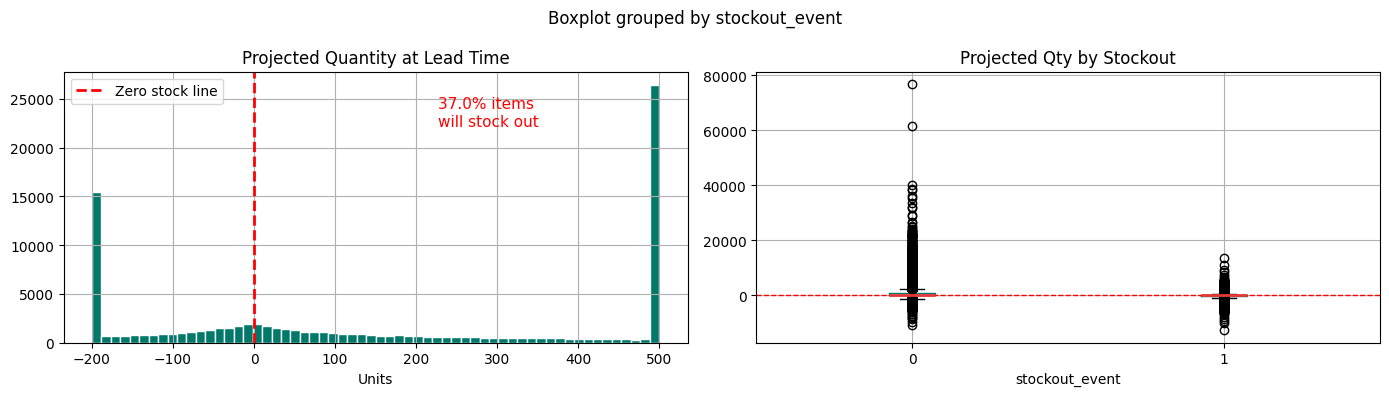

Items with projected_qty < 0: 37.0%
Stockout rate where projected_qty < 0: 42.3%


In [ ]:
# ── Projected quantity (key derived feature) ──────────────────────────────────
df['projected_qty'] = (df['current_stock_on_hand']
                       - df['avg_daily_usage_last_30d'] * df['actual_avg_lead_time_last_6m'])

pct_negative = (df['projected_qty'] < 0).mean()
pct_neg_stockout = df[df['projected_qty'] < 0]['stockout_event'].mean()

fig, axes = pt.subplots(1, 2, figsize=(14, 4))

df['projected_qty'].clip(-200, 500).hist(bins=60, ax=axes[0],
                                          color='#00796B', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='Zero stock line')
axes[0].set_title('Projected Quantity at Lead Time')
axes[0].set_xlabel('Units')
axes[0].legend()
axes[0].text(0.6, 0.8, f'{pct_negative*100:.1f}% items\nwill stock out',
             transform=axes[0].transAxes, color='red', fontsize=11)

df.boxplot(column='projected_qty', by='stockout_event', ax=axes[1],
           boxprops=dict(color='#00796B'),
           medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title('Projected Qty by Stockout')
axes[1].set_xlabel('stockout_event')
axes[1].axhline(0, color='red', linestyle='--', lw=1)

pt.tight_layout()
pt.show()

print(f'Items with projected_qty < 0: {pct_negative*100:.1f}%')
print(f'Stockout rate where projected_qty < 0: {pct_neg_stockout*100:.1f}%')

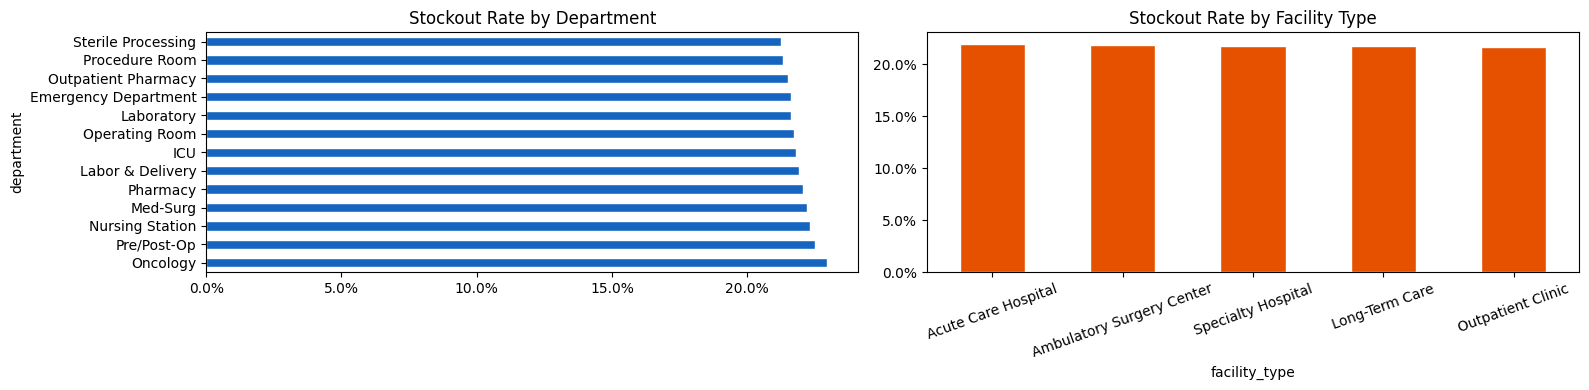

In [ ]:
# ── Stockout rate by department & facility ────────────────────────────────────
fig, axes = pt.subplots(1, 2, figsize=(16, 4))

dept_stockout = df.groupby('department')['stockout_event'].mean().sort_values(ascending=False)
dept_stockout.plot(kind='barh', ax=axes[0], color='#1565C0', edgecolor='white')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Stockout Rate by Department')

fac_stockout = df.groupby('facility_type')['stockout_event'].mean().sort_values(ascending=False)
fac_stockout.plot(kind='bar', ax=axes[1], color='#E65100', edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Stockout Rate by Facility Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

pt.tight_layout()
pt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

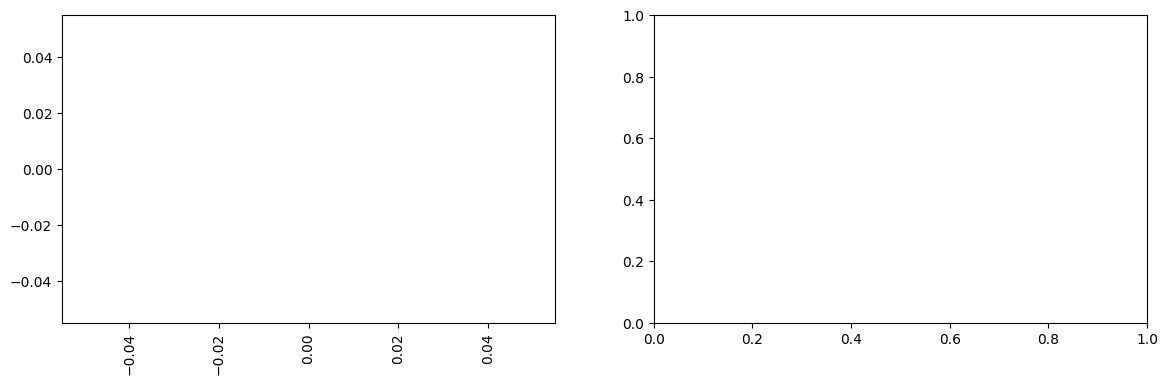

In [ ]:
# ── Census & surge flag impact ────────────────────────────────────────────────
fig, axes = pt.subplots(1, 2, figsize=(14, 4))

# Facility census vs stockout
df['census_bin'] = pd.cut(df['facility_census_pct'],
                           bins=[0, 0.5, 0.7, 0.85, 1.01],
                           labels=['Low (<50%)','Medium (50-70%)',
                                   'High (70-85%)','Full (>85%)'])
census_stockout = df.groupby('census_bin', observed=True)['stockout_event'].mean()
census_stockout.plot(kind='bar', ax=axes[0], color='#7B1FA2', edgecolor='white')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Stockout Rate by Census Level')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# Pandemic flag
surge_rate = df.groupby('pandemic_or_surge_flag')['stockout_event'].mean()
surge_rate.plot(kind='bar', ax=axes[1],
                color=['#42A5F5','#E53935'], edgecolor='white')
axes[1].set_xticklabels(['Normal','Pandemic/Surge'], rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Stockout Rate: Normal vs Pandemic/Surge')

pt.tight_layout()
pt.show()

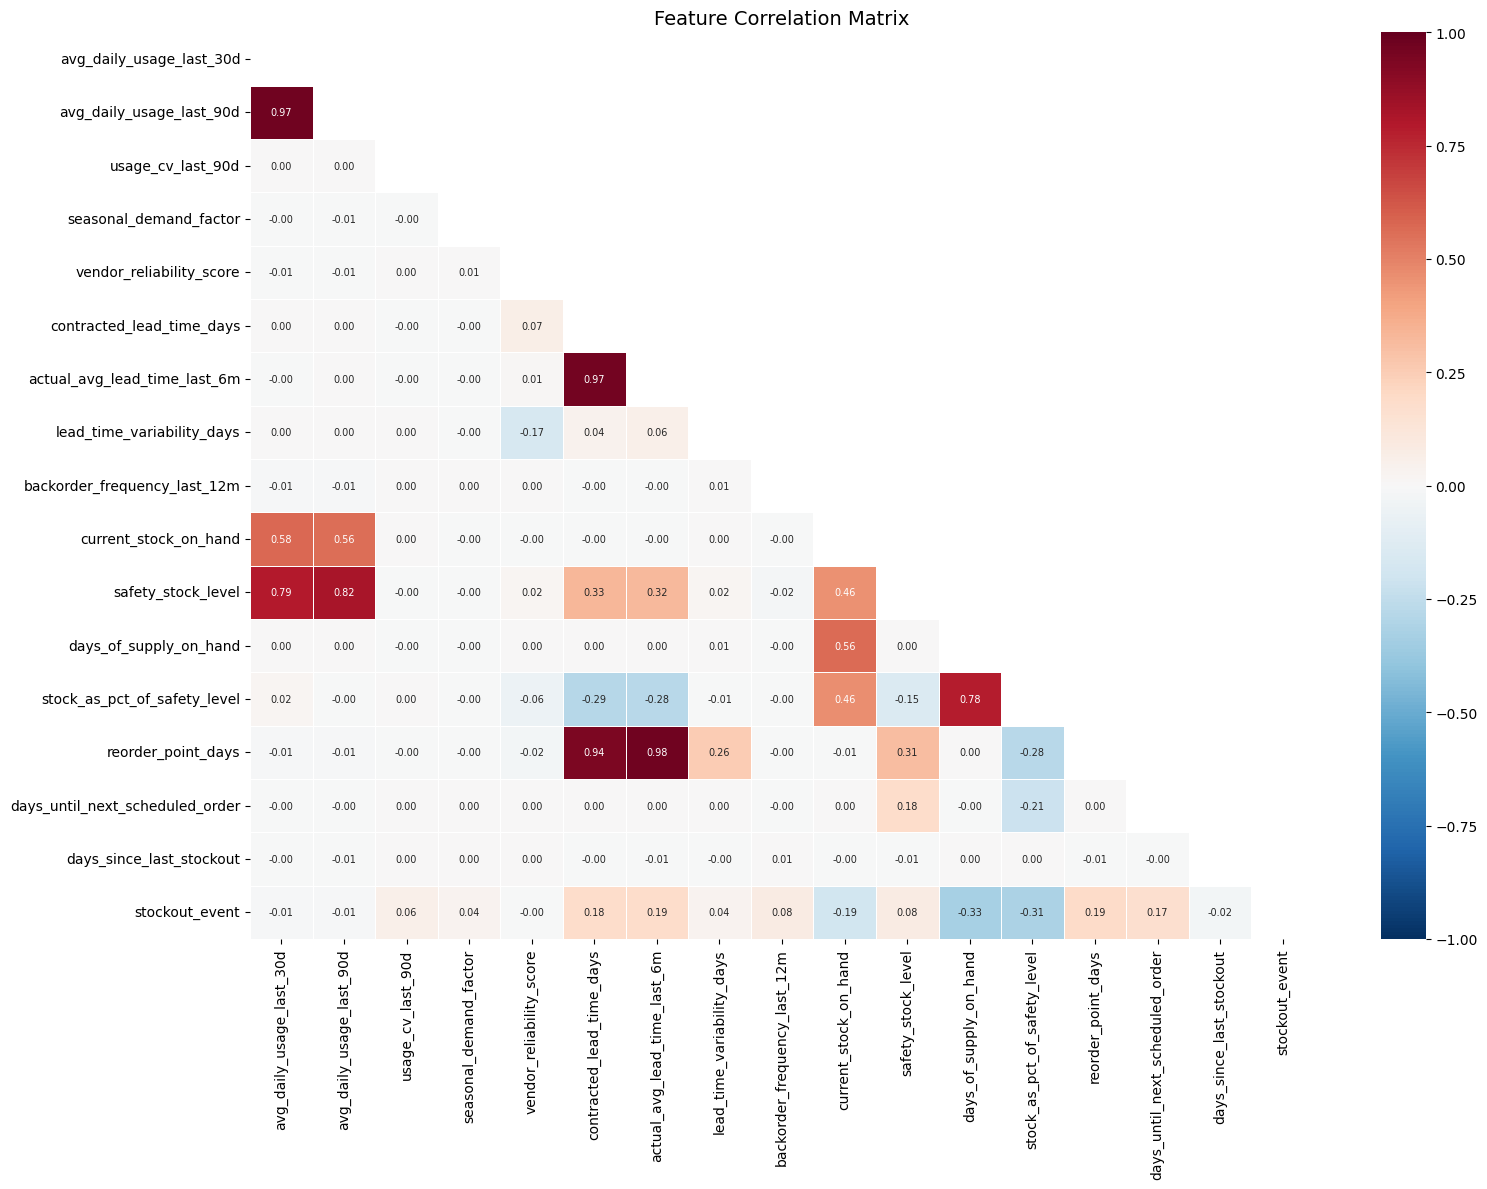

In [ ]:
# ── Correlation heatmap (numeric features only) ───────────────────────────────
numeric_cols = (DEMAND_FEATURES + SUPPLY_CHAIN_FEATURES
                + STOCK_FEATURES + ['stockout_event'])
numeric_cols = [c for c in numeric_cols if c in df.columns
                and pd.api.types.is_numeric_dtype(df[c])]

corr_matrix = df[numeric_cols].corr()

fig, ax = pt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sn.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14)
pt.tight_layout()
pt.show()

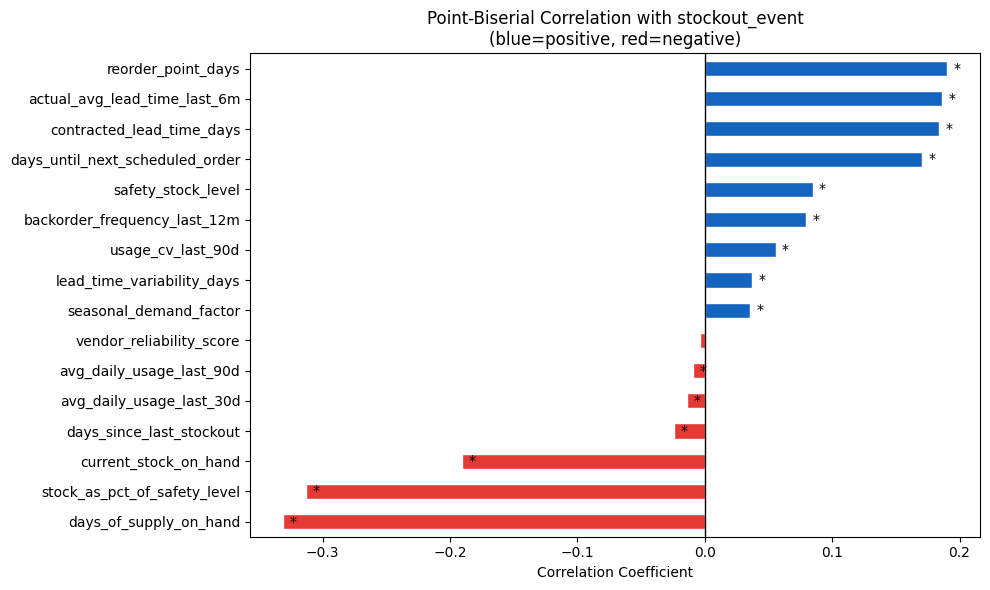

Top 5 features positively correlated with stockout:
                                 correlation        p_value
safety_stock_level                  0.084711  1.519834e-141
days_until_next_scheduled_order     0.170851   0.000000e+00
contracted_lead_time_days           0.184125   0.000000e+00
actual_avg_lead_time_last_6m        0.186421   0.000000e+00
reorder_point_days                  0.190039   0.000000e+00

Top 5 features negatively correlated with stockout:
                              correlation       p_value
days_of_supply_on_hand          -0.330820  0.000000e+00
stock_as_pct_of_safety_level    -0.312864  0.000000e+00
current_stock_on_hand           -0.190427  0.000000e+00
days_since_last_stockout        -0.023788  1.239359e-12
avg_daily_usage_last_30d        -0.013527  5.396884e-05


In [ ]:
# ── Point-biserial correlation with target ────────────────────────────────────
from scipy.stats import pointbiserialr

correlations = {}
for col in numeric_cols:
    if col == 'stockout_event':
        continue
    valid = df[[col, 'stockout_event']].dropna()
    if len(valid) > 30:
        r, p = pointbiserialr(valid['stockout_event'], valid[col])
        correlations[col] = {'correlation': r, 'p_value': p}

corr_df = pd.DataFrame(correlations).T.sort_values('correlation')
colors = ['#E53935' if v < 0 else '#1565C0' for v in corr_df['correlation']]

fig, ax = pt.subplots(figsize=(10, max(6, len(corr_df)*0.35)))
corr_df['correlation'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Point-Biserial Correlation with stockout_event\n(blue=positive, red=negative)', fontsize=12)
ax.set_xlabel('Correlation Coefficient')

# Mark significant features
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row['p_value'] < 0.05:
        ax.text(row['correlation'] + 0.005, i, '*', va='center', fontsize=10)

pt.tight_layout()
pt.show()

print('Top 5 features positively correlated with stockout:')
print(corr_df.tail(5)[['correlation','p_value']].to_string())
print('\nTop 5 features negatively correlated with stockout:')
print(corr_df.head(5)[['correlation','p_value']].to_string())

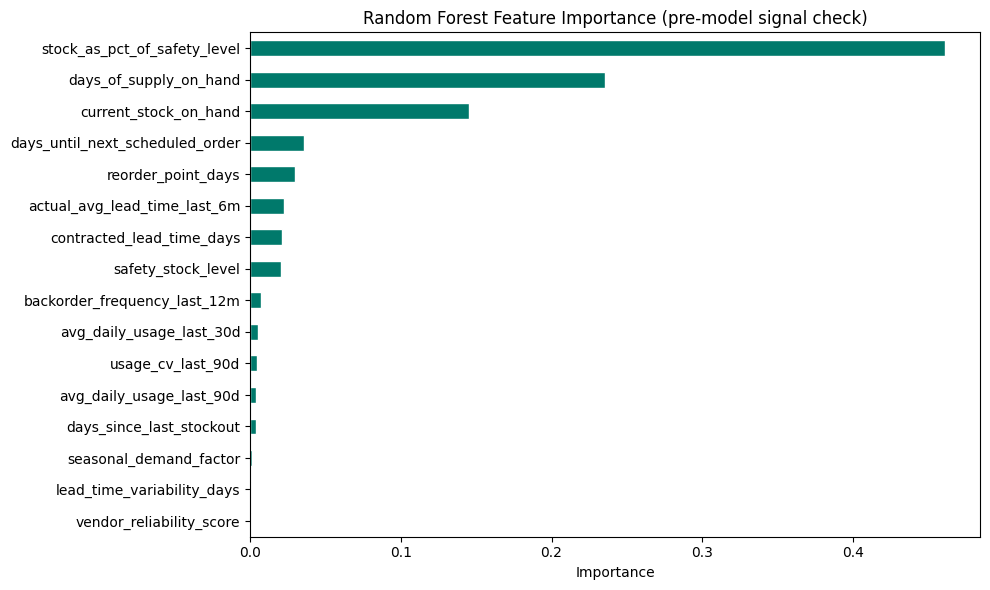

Top 10 most important features:
stock_as_pct_of_safety_level       0.461266
days_of_supply_on_hand             0.235404
current_stock_on_hand              0.145356
days_until_next_scheduled_order    0.035958
reorder_point_days                 0.030091
actual_avg_lead_time_last_6m       0.022408
contracted_lead_time_days          0.021223
safety_stock_level                 0.020329
backorder_frequency_last_12m       0.007030
avg_daily_usage_last_30d           0.005540


In [ ]:
# ── Quick Random Forest feature importance (pre-model signal check) ───────────

feature_cols = [c for c in numeric_cols if c != 'stockout_event']
X = df[feature_cols].fillna(df[feature_cols].median())
y = df['stockout_event'].fillna(0).astype(int)

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.Series(rf.feature_importances_,
                           index=feature_cols).sort_values(ascending=True)

fig, ax = pt.subplots(figsize=(10, max(6, len(importance_df)*0.35)))
importance_df.plot(kind='barh', ax=ax, color='#00796B', edgecolor='white')
ax.set_title('Random Forest Feature Importance (pre-model signal check)', fontsize=12)
ax.set_xlabel('Importance')
pt.tight_layout()
pt.show()

print('Top 10 most important features:')
print(importance_df.tail(10).sort_values(ascending=False).to_string())

In [ ]:
# ── Compute all derived features from architecture spec ───────────────────────
df['trend_ratio']       = (df['avg_daily_usage_last_30d']
                           / df['avg_daily_usage_last_90d'].replace(0, np.nan))

df['projected_qty']     = (df['current_stock_on_hand']
                           - df['avg_daily_usage_last_30d'] * df['actual_avg_lead_time_last_6m'])

df['lead_time_bias']    = (df['actual_avg_lead_time_last_6m']
                           - df['contracted_lead_time_days'])

df['supply_risk_score'] = (df['backorder_frequency_last_12m']
                           * df['lead_time_variability_days']
                           / df['vendor_reliability_score'].clip(0.01))

# Additional derived features
df['days_to_stockout']  = (df['current_stock_on_hand']
                           / df['avg_daily_usage_last_30d'].replace(0, np.nan))

df['safety_buffer']     = df['days_to_stockout'] - df['actual_avg_lead_time_last_6m']

derived = ['trend_ratio','projected_qty','lead_time_bias',
           'supply_risk_score','days_to_stockout','safety_buffer']

print('Derived features computed ✅')
df[derived].describe().round(2)

Derived features computed ✅


,trend_ratio,projected_qty,lead_time_bias,supply_risk_score,days_to_stockout,safety_buffer
count,89088.00,89088.00,89088.00,89088.00,89088.00,89088.00
mean,1.02,507.48,0.67,0.46,21.83,11.50
std,0.18,1582.84,1.87,0.96,22.09,23.18
min,0.45,-12743.19,-7.30,0.00,0.00,-42.20
25%,0.89,-86.00,-0.20,0.00,5.69,-3.69
50%,1.00,101.80,0.30,0.14,13.70,4.59
75%,1.13,649.30,1.10,0.53,32.00,22.43
max,2.22,76765.86,26.00,31.60,120.00,118.40


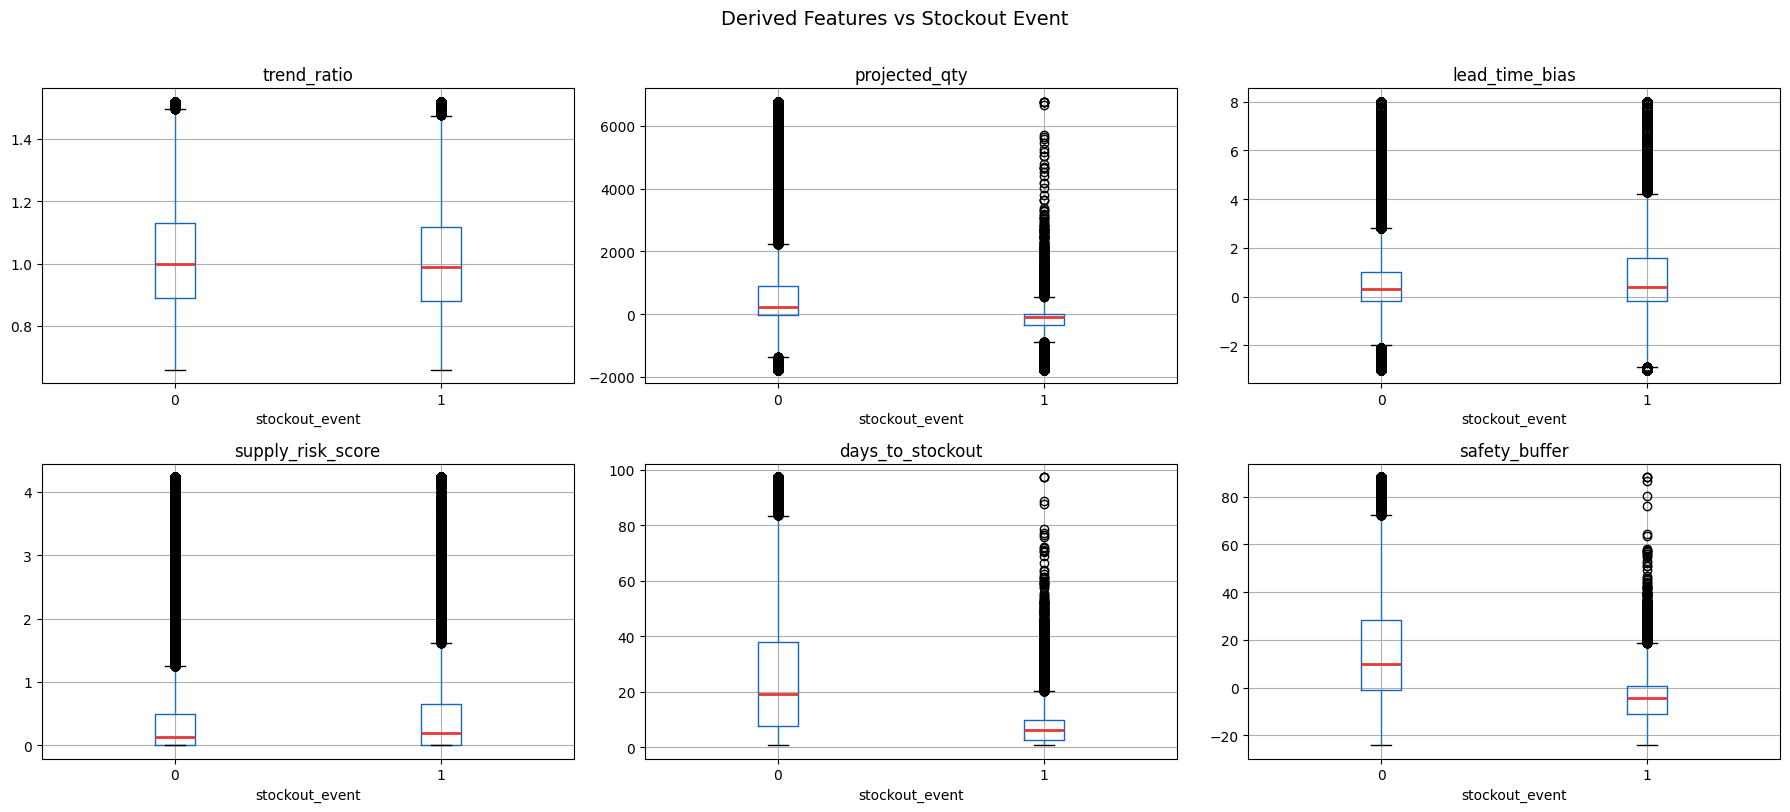

In [ ]:
# ── Derived features vs stockout ──────────────────────────────────────────────
fig, axes = pt.subplots(2, 3, figsize=(18, 8))
axes_flat = axes.flatten()

for i, col in enumerate(derived):
    data = df[[col,'stockout_event']].dropna()
    data[col] = data[col].clip(data[col].quantile(0.01), data[col].quantile(0.99))
    data.boxplot(column=col, by='stockout_event', ax=axes_flat[i],
                 boxprops=dict(color='#1565C0'),
                 medianprops=dict(color='#E53935', linewidth=2))
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel('stockout_event')

pt.suptitle('Derived Features vs Stockout Event', y=1.01, fontsize=14)
pt.tight_layout()
pt.show()

In [ ]:
# ── Final summary statistics ──────────────────────────────────────────────────
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)

print(f'\n📦 Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'🗓  Date range: {df["snapshot_date"].min().date()} → {df["snapshot_date"].max().date()}')
print(f'🔑 Unique time series: {df.groupby(["facility_id","department","item_id"]).ngroups:,}')

print(f'\n🎯 TARGET')
print(f'   Stockout rate: {df["stockout_event"].mean()*100:.2f}%')
print(f'   Class imbalance ratio: {imbalance_ratio:.1f}:1')

print(f'\n📊 DEMAND')
print(f'   Items with accelerating demand (30d/90d > 1.2): {(df["trend_ratio"]>1.2).sum():,}')
print(f'   Usage CV > 0.5 (high variability): {(df["usage_cv_last_90d"]>0.5).sum():,}')

print(f'\n🚚 SUPPLY CHAIN')
print(f'   Vendors delivering late: {(df["lead_time_bias"]>0).mean()*100:.1f}%')
print(f'   Sole-source items: {df["sole_source_item"].sum():,}')

print(f'\n📉 STOCK POSITION')
print(f'   Items projected to stock out before delivery: {(df["projected_qty"]<0).sum():,}')
print(f'   Items below safety stock now: {(df["stock_as_pct_of_safety_level"]<100).sum():,}')

print(f'\n✅ RECOMMENDATIONS FOR ML PIPELINE')
print('   1. Use SMOTE or class_weight="balanced" (imbalanced classes)')
print('   2. Use projected_qty & safety_buffer as top engineered features')
print('   3. Time-based train/val/test split (no random shuffle)')
print('   4. Separate model for pandemic_or_surge_flag==1 rows')
print('   5. Use stratified CV by criticality_level')
print('   6. Evaluate with F1, AUROC, Precision@K (top-K alerts)')

EDA SUMMARY

📦 Dataset: 89,088 rows, 45 columns


AttributeError: 'str' object has no attribute 'date'